### Imports

In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


### Load data:

In [ ]:
# Load data and labels
X = np.load('/Users/nataliamorenoblasco/Desktop/AffectiveComputing_SpeechRecognition/Affective-Computing---Speech-Emotion-Recognition/Data/X_merged_new.npy')
y = np.load('/Users/nataliamorenoblasco/Desktop/AffectiveComputing_SpeechRecognition/Affective-Computing---Speech-Emotion-Recognition/Data/y_merged_new.npy')

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1440, 39, 128)
y shape: (1440,)


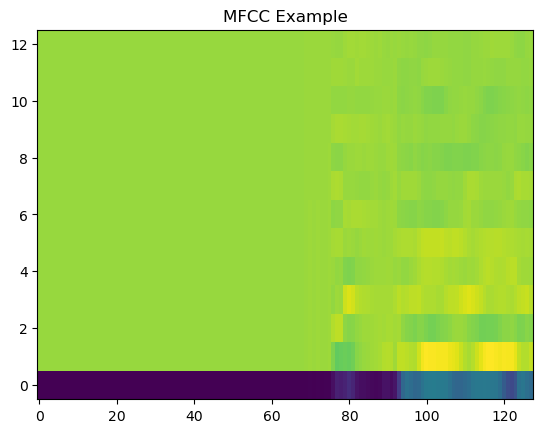

In [4]:
import matplotlib.pyplot as plt
plt.imshow(X[0], aspect='auto', origin='lower')
plt.title("MFCC Example")
plt.show()


1440 samples
13 MFCCs coefficients per time frame
128 time frames
- So each sample is a matrix of 13 x 128.

In [7]:
for i in range(5):
    print(f"\n--- Sample {i} ---")
    print("Label:", y[i])
    print("MFCC shape:", X[i].shape)
    print("MFCC values (first 3 coefficients x first 10 time steps):")
    print(np.round(X[i][:3, :10], 3))  # print a small portion nicely rounded


--- Sample 0 ---
Label: 0
MFCC shape: (13, 128)
MFCC values (first 3 coefficients x first 10 time steps):
[[-861.533 -861.533 -861.533 -861.533 -861.533 -861.533 -861.533 -861.533
  -861.533 -861.533]
 [   0.       0.       0.       0.       0.       0.       0.       0.
     0.       0.   ]
 [   0.       0.       0.       0.       0.       0.       0.       0.
     0.       0.   ]]

--- Sample 1 ---
Label: 0
MFCC shape: (13, 128)
MFCC values (first 3 coefficients x first 10 time steps):
[[-861.444 -861.444 -861.444 -861.444 -861.444 -861.444 -861.444 -861.444
  -861.444 -858.974]
 [   0.       0.       0.       0.       0.       0.       0.       0.
     0.       3.483]
 [   0.       0.       0.       0.       0.       0.       0.       0.
     0.       3.454]]

--- Sample 2 ---
Label: 0
MFCC shape: (13, 128)
MFCC values (first 3 coefficients x first 10 time steps):
[[-845.508 -844.325 -844.297 -844.206 -841.289 -840.632 -845.18  -847.255
  -848.919 -844.191]
 [   8.058    9.718    9

In [ ]:
unique, counts = np.unique(y, return_counts=True)
print("Unique labels:", unique)
print("Counts per label:", counts)

Unique labels: [0 1 2 3 4 5 6 7]
Counts per label: [ 96 192 192 192 192 192 192 192]


### Scaling:

In [5]:
X_reshaped = X.reshape(X.shape[0], -1) # reshaped X to 2D for scaling: (samples, features) bc StandardScaler needs 2D input
scaler = StandardScaler() # z-score normalization --> all features have 0 mean and unit variance (std 1)
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X.shape) # Reshaped back to original 3D format (samples, 13, 128)

print("Scaled X shape:", X_scaled.shape)
print("Mean after scaling:", np.mean(X_scaled))
print("Std after scaling:", np.std(X_scaled))

Scaled X shape: (1440, 13, 128)
Mean after scaling: 1.2634147e-08
Std after scaling: 0.99999994


### Data split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1152, 13, 128) Test: (288, 13, 128)


### Models

#### Simple DNN

In [7]:
# PyTorch tensors:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [ ]:
class sDNN(nn.Module):
    def __init__(self):
        super(sDNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(13 * 128, 512)
        self.drop1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(512, 256)
        self.drop2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(256, 128)
        self.drop3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(128, 8)  # 8 emotion classes (0–7)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        x = F.relu(self.fc3(x))
        x = self.drop3(x)
        x = self.fc4(x)  # logits (no softmax)
        return x

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = sDNN().to(device)

criterion = nn.CrossEntropyLoss()  # since y are integer labels
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {train_loss:.4f}  Accuracy: {train_acc:.4f}")


Epoch [1/50]  Loss: 1.9033  Accuracy: 0.2396
Epoch [2/50]  Loss: 1.6440  Accuracy: 0.3594
Epoch [3/50]  Loss: 1.4295  Accuracy: 0.4757
Epoch [4/50]  Loss: 1.2423  Accuracy: 0.5391
Epoch [5/50]  Loss: 1.0476  Accuracy: 0.6068
Epoch [6/50]  Loss: 0.9122  Accuracy: 0.6675
Epoch [7/50]  Loss: 0.7866  Accuracy: 0.7083
Epoch [8/50]  Loss: 0.6877  Accuracy: 0.7578
Epoch [9/50]  Loss: 0.5790  Accuracy: 0.7986
Epoch [10/50]  Loss: 0.5659  Accuracy: 0.8090
Epoch [11/50]  Loss: 0.4441  Accuracy: 0.8446
Epoch [12/50]  Loss: 0.4372  Accuracy: 0.8524
Epoch [13/50]  Loss: 0.4015  Accuracy: 0.8776
Epoch [14/50]  Loss: 0.3545  Accuracy: 0.8845
Epoch [15/50]  Loss: 0.2762  Accuracy: 0.8984
Epoch [16/50]  Loss: 0.3092  Accuracy: 0.8967
Epoch [17/50]  Loss: 0.2980  Accuracy: 0.9002
Epoch [18/50]  Loss: 0.2382  Accuracy: 0.9123
Epoch [19/50]  Loss: 0.1945  Accuracy: 0.9340
Epoch [20/50]  Loss: 0.2746  Accuracy: 0.9062
Epoch [21/50]  Loss: 0.2413  Accuracy: 0.9245
Epoch [22/50]  Loss: 0.1999  Accuracy: 0.93

In [11]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.3f}")


Test Accuracy: 0.448


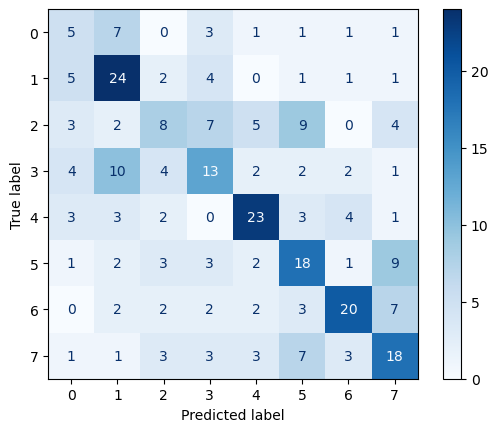

In [ ]:
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(device))
        _, preds = torch.max(outputs, 1)
        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.show()
